In [2]:
# Loading data
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [3]:
# Scaling
X_train = X_train/255
X_test = X_test/255

In [4]:
# one-hot encode labels
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## AlexNet Architecture :-

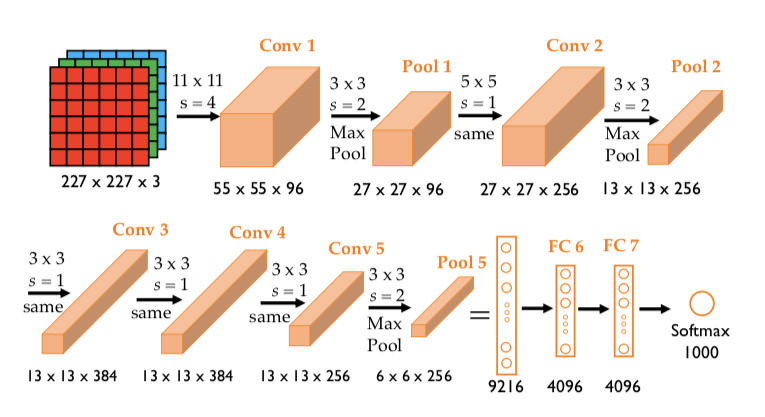

In [5]:
# Defining Alexnet model
from tensorflow.keras import Sequential, layers

model = Sequential([
    # Layer 1
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(96, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization(),

    # Layer 2
    layers.Conv2D(256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),
    layers.BatchNormalization(),

    # Layer 3
    layers.Conv2D(384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),

    # Layer 4
    layers.Conv2D(384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),

    # Layer 5
    layers.Conv2D(256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    layers.Flatten(),

    # FCL layer 1
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),

    # FCL layer 2
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(10, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,048,394 (30.70 MB)

 Trainable params: 8,047,690 (30.70 MB)

 Non-trainable params: 704 (2.75 KB)

In [6]:
with tf.device('/device:GPU:0'):
  model.fit(X_train, y_train, batch_size=128, epochs=15)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.3466 - loss: 1.7877
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5971 - loss: 1.1333
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6861 - loss: 0.8935
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7521 - loss: 0.7315
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7849 - loss: 0.6288
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8213 - loss: 0.5320
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8424 - loss: 0.4589
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8712 - loss: 0.3819
Epoch 9/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8893 - loss: 0.3275
Epoch 10/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9094 - loss: 0.2710
Epoch 11/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9166 - loss: 0.2529
Epoch 12/15
391/391 ━━━━━━━━━━

In [7]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7818 - loss: 0.8738


[0.8794240951538086, 0.7843999862670898]

In [9]:
y_pred = model.predict(X_test)
y_pred = [np.argmax(val) for val in y_pred]
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(6)]

In [11]:
y_test = [np.argmax(val) for val in y_test]
y_test[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

<Axes: >

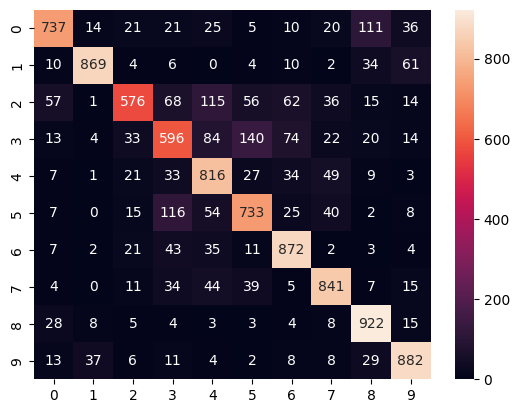

In [12]:
import seaborn as sns
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.74      0.78      1000
           1       0.93      0.87      0.90      1000
           2       0.81      0.58      0.67      1000
           3       0.64      0.60      0.62      1000
           4       0.69      0.82      0.75      1000
           5       0.72      0.73      0.73      1000
           6       0.79      0.87      0.83      1000
           7       0.82      0.84      0.83      1000
           8       0.80      0.92      0.86      1000
           9       0.84      0.88      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.78     10000
weighted avg       0.79      0.78      0.78     10000

